# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [101]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset
import re
from wordcloud import WordCloud, STOPWORDS
# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [80]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", streaming=True, split="train",cache_dir="../data")
df = ds.to_pandas()


DATA_PATH = "../data/all-the-news-2-1-Component-one-sampled.csv"


## Lectura de Datos

In [69]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,None,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,None,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,None,Vox


In [70]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idx          30213 non-null  int64 
 1   article_idx  30213 non-null  int64 
 2   date         30213 non-null  object
 3   year         30213 non-null  object
 4   month        30213 non-null  object
 5   day          30213 non-null  object
 6   author       18808 non-null  object
 7   title        30213 non-null  object
 8   article      29037 non-null  object
 9   url          30072 non-null  object
 10  section      19981 non-null  object
 11  publication  30072 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.8+ MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [71]:
# TODO: Analice datos faltantes por columna
largo=len(df)

for columna, contenido in df.items()    :

    if contenido.isnull().sum() > 0:
        print(f"Columna {columna} tiene {df[columna].isnull().sum()} valores nulos, ({100*df[columna].isnull().sum()/largo}%)")


nulos = df.isnull().sum()
#print(f"\nColumnas con valores nulos:\n{nulos[nulos > 0]}")

print('\n')
print('='*80)


Columna author tiene 11405 valores nulos, (37.748651242842485%)
Columna article tiene 1176 valores nulos, (3.8923642140800316%)
Columna url tiene 141 valores nulos, (0.4666865256677589%)
Columna section tiene 10232 valores nulos, (33.86621652930857%)
Columna publication tiene 141 valores nulos, (0.4666865256677589%)




In [128]:
print('Evaluación de calidad de date')
#VER INCONSISTENCIA EN FECHAS de DATE
#print(f"\n{df['date'].astype(str).apply(len).unique()}")
#Los que tienen largo 10 son DD/MM/YYYY, los de 19 contienen HH:MM:SS
largo = df['date'].astype(str).apply(len)
sin_hora = (largo == 10).sum()
con_hora = (largo == 19).sum()

print(f"Largo 10 (solo fecha): {sin_hora} ({100*sin_hora/len(df):.2f}%)")
print(f"Largo 19 (fecha + hora): {con_hora} ({100*con_hora/len(df):.2f}%)")

#Valido si las columnas year,month y date tienen la misma fecha que date
# Construir fecha desde columnas separadas
# Copia limpia de date como string
date_str = df['date'].astype(str).str.strip()

# Identificar formatos por largo
mask_10 = date_str.str.len() == 10   # YYYY-MM-DD
mask_19 = date_str.str.len() == 19   # YYYY-MM-DD HH:MM:SS

# Crear columna vacía
df['date_parsed'] = pd.NaT

# Parsear cada formato por separado
df.loc[mask_10, 'date_parsed'] = pd.to_datetime(
    date_str[mask_10],
    format='%Y-%m-%d',
    errors='coerce'
)

df.loc[mask_19, 'date_parsed'] = pd.to_datetime(
    date_str[mask_19],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)
# Convertir columnas auxiliares a numérico
df['year_num'] = pd.to_numeric(df['year'], errors='coerce')
df['month_num'] = pd.to_numeric(df['month'], errors='coerce')
df['day_num'] = pd.to_numeric(df['day'], errors='coerce')

# Comparar componentes de fecha
coinciden = (
    (df['date_parsed'].dt.year == df['year_num']) &
    (df['date_parsed'].dt.month == df['month_num']) &
    (df['date_parsed'].dt.day == df['day_num'])
)

# Todo lo que no sea True cuenta como no coincide
coinciden = coinciden.fillna(False)
total = len(df)
ok = coinciden.sum()
no_ok = (~coinciden).sum()
print(f"Coinciden: {ok} ({100*ok/total:.2f}%)")


Evaluación de calidad de date
Largo 10 (solo fecha): 10799 (35.74%)
Largo 19 (fecha + hora): 19414 (64.26%)
Coinciden: 30213 (100.00%)


In [100]:


print('='*80)
print('Evaluación de calidad de article')

df['article'] = df['article'].astype('string')
df['article_length'] = df['article'].fillna('').str.len()
df['article_words'] = df['article'].fillna('').str.split().str.len()

total = len(df)

prom_length = df['article_length'].mean()
prom_words = df['article_words'].mean()

# Artículos muy cortos (<20 caracteres)
cortos_20 = (df['article_length'] < 20).sum()

print(f"Promedio de longitud de artículos: {prom_length:.2f} caracteres")
print(f"Promedio de cantidad de palabras por artículo: {prom_words:.2f} palabras")
print(f"Artículos muy cortos (<20 caracteres): {cortos_20} ({100*cortos_20/total:.2f}%)")
print("\nEjemplos de artículos muy cortos (<20 caracteres):")
print(
    df.loc[
        (df['article_length'] < 20) & (df['article'].notna()) & (df['article'].str.strip() != ''),
        ['article']
    ].head(5)
)


Evaluación de calidad de article
Promedio de longitud de artículos: 2997.79 caracteres
Promedio de cantidad de palabras por artículo: 495.36 palabras
Artículos muy cortos (<20 caracteres): 1188 (3.93%)

Ejemplos de artículos muy cortos (<20 caracteres):
                 article
409               (CNN) 
447               (CNN) 
699    Credit Cheney Orr
10751  Credit Cheney Orr
15421  Credit Cheney Orr


In [114]:
print('='*80)
print('Evaluación de unicidad (con publication)')

total = len(df)

mask_article = df['article'].notna() & (df['article'].str.strip() != '')
mask_title   = df['title'].notna()   & (df['title'].str.strip() != '')
mask_url     = df['url'].notna()     & (df['url'].astype(str).str.strip() != '')
mask_pub     = df['publication'].notna() & (df['publication'].astype(str).str.strip() != '')

# --- duplicados simples ---
dup_article = df[mask_article].duplicated(subset=['article']).sum()
dup_title   = df[mask_title].duplicated(subset=['title']).sum()
dup_url     = df[mask_url].duplicated(subset=['url']).sum()

# --- cruzados con publication ---
dup_article_pub = df[mask_article & mask_pub].duplicated(subset=['article','publication']).sum()
dup_title_article_pub = df[mask_title & mask_article & mask_pub].duplicated(subset=['title','article','publication']).sum()
dup_t_a_u_pub = df[mask_title & mask_article & mask_url & mask_pub].duplicated(subset=['title','article','url','publication']).sum()

print(f"Duplicados por article: {dup_article} ({100*dup_article/total:.2f}%)")
print(f"Duplicados por title: {dup_title} ({100*dup_title/total:.2f}%)")
print(f"Duplicados por url: {dup_url} ({100*dup_url/total:.2f}%)")

print(f"Duplicados por article + publication: {dup_article_pub} ({100*dup_article_pub/total:.2f}%)")
print(f"Duplicados por title + article + publication: {dup_title_article_pub} ({100*dup_title_article_pub/total:.2f}%)")
print(f"Duplicados por title + article + url + publication: {dup_t_a_u_pub} ({100*dup_t_a_u_pub/total:.2f}%)")

print("\nEjemplos duplicados por title + article + publication:")
print(
    df.loc[mask_title & mask_article & mask_pub]
      .loc[lambda x: x.duplicated(subset=['title','article','publication'], keep=False),
           ['publication','title','article']]
      .head(10)
)

Evaluación de unicidad (con publication)
Duplicados por article: 108 (0.36%)
Duplicados por title: 325 (1.08%)
Duplicados por url: 0 (0.00%)
Duplicados por article + publication: 108 (0.36%)
Duplicados por title + article + publication: 13 (0.04%)
Duplicados por title + article + url + publication: 0 (0.00%)

Ejemplos duplicados por title + article + publication:
              publication                                              title  \
653                 Axios                                    Axios Morning 5   
1382              Reuters  Deutsche Bank shifts euro clearing as post-Bre...   
3974   The New York Times                      Covid-19’s Impact in the U.S.   
4201              Reuters  China's Tibet closes tourism sites to prevent ...   
7150              Reuters  Deutsche Bank shifts euro clearing as post-Bre...   
9495              Reuters  Mastercard to add 1,500 technology jobs in Ire...   
11266  The New York Times                            Coronavirus in the U.

In [146]:
# TODO: Analice la cantidad de artículos por medio de prensa

# eliminar duplicados por title + article + publication
df_unique = df.drop_duplicates(subset=['title', 'article', 'publication'])

# conteo por medio
publications = df_unique['publication'].value_counts()

top_5_publications = publications.head(5)

print(f"\nLos 5 medios con más artículos (sin duplicados) son:\n{top_5_publications}")

# filtrar top 5
df_top_5 = df_unique[df_unique['publication'].isin(top_5_publications.index)]


Los 5 medios con más artículos (sin duplicados) son:
publication
Reuters               9424
The New York Times    2834
CNBC                  2601
The Hill              2349
People                1528
Name: count, dtype: int64


In [121]:
# TODO: Analice datos faltantes por columna
largo=len(df)

for columna, contenido in df.items()    :

    if contenido.isnull().sum() > 0:
        print(f"Columna {columna} tiene {df[columna].isnull().sum()} valores nulos, ({100*df[columna].isnull().sum()/largo}%)")


nulos = df.isnull().sum()
#print(f"\nColumnas con valores nulos:\n{nulos[nulos > 0]}")

print('\n')
print('='*80)


Columna author tiene 11405 valores nulos, (37.748651242842485%)
Columna article tiene 1176 valores nulos, (3.8923642140800316%)
Columna url tiene 141 valores nulos, (0.4666865256677589%)
Columna section tiene 10232 valores nulos, (33.86621652930857%)
Columna publication tiene 141 valores nulos, (0.4666865256677589%)




## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

Index(['idx', 'article_idx', 'date', 'year', 'month', 'day', 'author', 'title',
       'article', 'url', 'section', 'publication', 'article_length',
       'article_words', 'article_strip_diff', 'has_url', 'has_email',
       'has_html', 'has_many_spaces', 'date_parsed', 'year_num', 'month_num',
       'day_num', 'fecha', 'mes'],
      dtype='object')


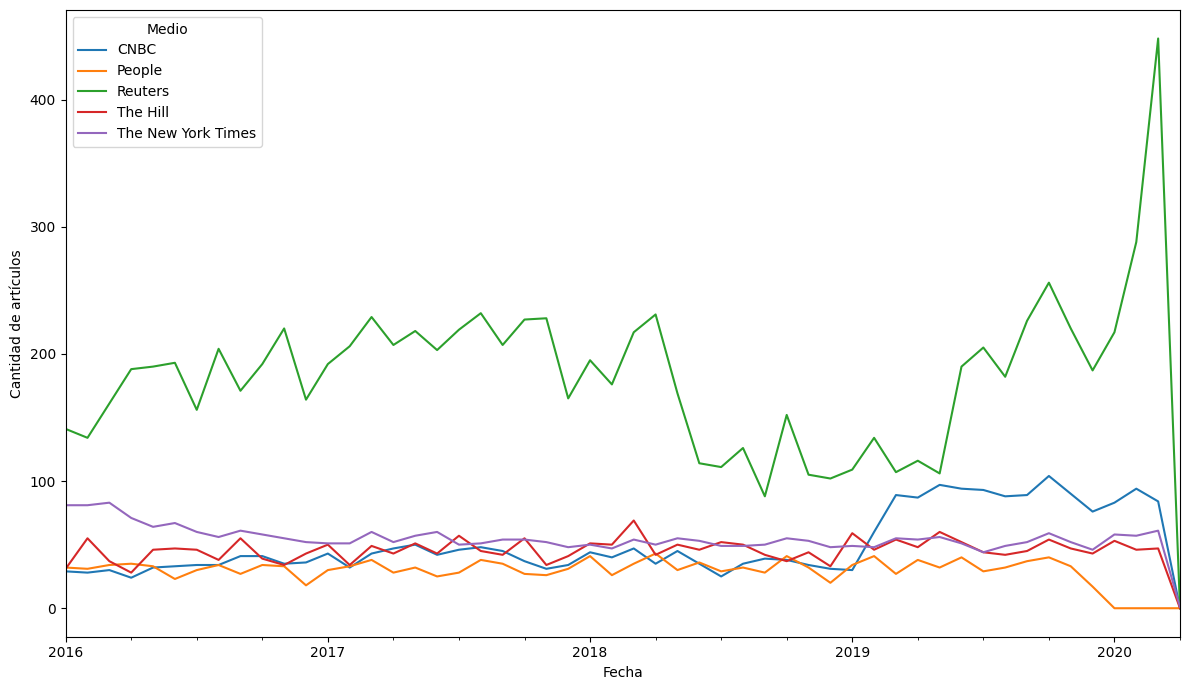

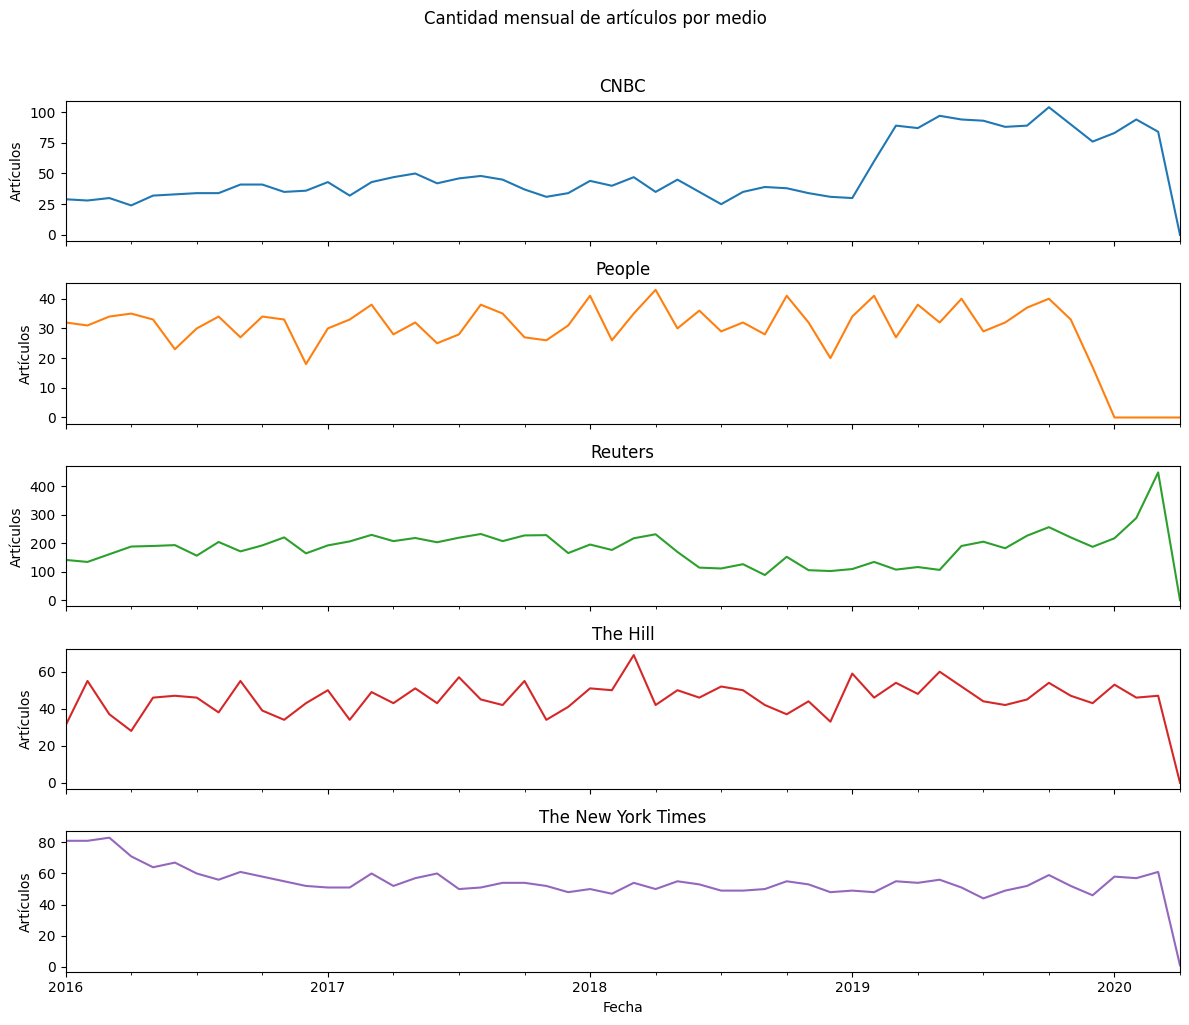

In [134]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo

df_top_5 = df_top_5.copy()
print(df_top_5.columns)

# Usar la fecha ya parseada correctamente
df_top_5['fecha'] = pd.to_datetime(df_top_5['date_parsed'], errors='coerce')

# Eliminar registros sin fecha válida
df_top_5 = df_top_5[df_top_5['fecha'].notna()]

# Agrupar por mes para suavizar la visualización
df_top_5['mes'] = df_top_5['fecha'].dt.to_period('M').dt.to_timestamp()
# detectar último mes completo
ultimo_mes = df_top_5['mes'].max()

# eliminar ese mes
df_plot = df_top_5[df_top_5['mes'] < ultimo_mes]

plot_df = (
    df_top_5
    .groupby(['mes', 'publication'])
    .size()
    .unstack(fill_value=0)
)

# Gráfico conjunto
ax = plot_df.plot(figsize=(12, 7))

ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de artículos')
ax.legend(title='Medio')
plt.tight_layout()
plt.show()

axes = plot_df.plot(
    subplots=True,
    figsize=(12, 10),
    sharex=True,
    sharey=False,
    legend=False
)

for ax, medio in zip(axes, plot_df.columns):
    ax.set_title(medio)
    ax.set_ylabel('Artículos')

axes[-1].set_xlabel('Fecha')
plt.suptitle('Cantidad mensual de artículos por medio', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Analice datos faltantes por columna
largo=len(df)

for columna, contenido in df.items()    :

    if contenido.isnull().sum() > 0:
        print(f"Columna {columna} tiene {df[columna].isnull().sum()} valores nulos, ({100*df[columna].isnull().sum()/largo}%)")


nulos = df.isnull().sum()
#print(f"\nColumnas con valores nulos:\n{nulos[nulos > 0]}")

print('\n')
print('='*80)


Columna author tiene 11405 valores nulos, (37.748651242842485%)
Columna article tiene 1176 valores nulos, (3.8923642140800316%)
Columna url tiene 141 valores nulos, (0.4666865256677589%)
Columna section tiene 10232 valores nulos, (33.86621652930857%)
Columna publication tiene 141 valores nulos, (0.4666865256677589%)




## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [149]:
def clean_text(df, column_name):

    result = df[column_name].astype("string")

    # eliminar encabezado
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # minúsculas
    result = result.str.lower()

    # eliminar todo lo que no sea letra o espacio
    result = result.str.replace(r'[^a-z\s]', ' ', regex=True)

    # normalizar espacios
    result = result.str.replace(r'\s+', ' ', regex=True).str.strip()

    return result

df_top_5 = df_top_5.copy()

df_top_5["article_clean"] = clean_text(df_top_5, "article")

print("Antes de limpiar:")
print(df_top_5["article"].dropna().iloc[10][:1000])

print("\nDespués de limpiar:")
print(df_top_5["article_clean"].dropna().iloc[10][:1000])

Antes de limpiar:
HOUSTON (Reuters) - An outage on a major pipeline from the largest oil hub in the United States would normally send shockwaves through crude markets, but that has not happened this week as Enterprise Products Partners’ 400,000-barrel-per-day (bpd) Seaway pipeline enters its second day offline. That is because shipping capacity on the route from Cushing, Oklahoma to the U.S. Gulf Coast has roughly tripled over the last three years as midstream companies raced to expand for the North American shale oil boom only to see it disappear. Even with no clear timeline for a restart of the pipeline or scope of the damage, the response from both physical and futures markets has been muted. On Tuesday, the discount for prompt futures relative to the second month rebounded slightly from Monday’s lows, trading at 62 cents per barrel. Enterprise took the 850,000 bpd Seaway Crude system out of service after one of the lines suffered a leak late Sunday night. The company restarted on M

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Conviene usar Clea_Text tanto en el titulo como en el contenido del articulo. Ambos tienen en su version original muchos simbolos de puntuacion que pueden dificultar su procesamiento posterior y no agregan valor en el analisis. 

*TODO: Escriba su análisis en el informe.*

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [156]:
print('='*80)
print('E. Pistas que identifican al medio de prensa')

df_top_5 = df_top_5.copy()

# Asegurar texto limpio disponible
if 'article_clean' not in df_top_5.columns:
    df_top_5['article_clean'] = clean_text(df_top_5, 'article')

# Alias simples para buscar nombres del medio
aliases = {
    'Reuters': ['reuters'],
    'CNBC': ['cnbc'],
    'People': ['people'],
    'The Hill': ['the hill', 'thehill'],
    'The New York Times': ['new york times', 'nytimes']
}

resultados = []

for medio in df_top_5['publication'].dropna().unique():
    df_medio = df_top_5[df_top_5['publication'] == medio].copy()
    patrones = aliases.get(medio, [medio.lower()])
    
    contiene_medio = df_medio['article_clean'].str.contains(
        '|'.join(patrones),
        case=False,
        na=False,
        regex=True
    )
    
    total = len(df_medio)
    cantidad = contiene_medio.sum()
    porcentaje = 100 * cantidad / total if total > 0 else 0
    
    resultados.append({
        'medio': medio,
        'total_articulos': total,
        'menciones_nombre_medio': cantidad,
        'porcentaje': porcentaje
    })

df_pistas_medio = pd.DataFrame(resultados).sort_values('porcentaje', ascending=False)

print('\nPorcentaje de artículos donde aparece el nombre del medio en el texto:')
print(df_pistas_medio)



E. Pistas que identifican al medio de prensa

Porcentaje de artículos donde aparece el nombre del medio en el texto:
                medio  total_articulos  menciones_nombre_medio  porcentaje
2            The Hill             2349                    2335   99.404002
0             Reuters             9424                    8352   88.624788
4              People             1528                    1041   68.128272
1                CNBC             2601                     901   34.640523
3  The New York Times             2834                     647   22.829922


In [164]:
print('\n' + '='*80)
print('Análisis de autores')

# limpiar authors válidos
df_auth = df_top_5[
    (df_top_5['author'].notna()) &
    (df_top_5['author'].astype(str).str.strip() != '')
].copy()

print('\n' + '='*80)
print('Porcentaje TOTAL de artículos con menciones de autores')

# trabajar solo con artículos que tienen author
df_auth = df_top_5[
    (df_top_5['author'].notna()) &
    (df_top_5['author'].astype(str).str.strip() != '')
].copy()

# check fila a fila (mucho más liviano)
contiene_autor = df_auth.apply(
    lambda row: str(row['author']).lower() in str(row['article_clean']),
    axis=1
)

articulos_con_autor = contiene_autor.sum()
total_articulos = len(df_top_5)

porcentaje_total = 100 * articulos_con_autor / total_articulos

print(f"Artículos con mención de su autor: {articulos_con_autor}")
print(f"Porcentaje sobre el total: {porcentaje_total:.2f}%")# ============================================================
# autores presentes en más de un medio (listar medios)
# ============================================================

print('\n' + '='*80)
print('Autores presentes en más de un medio (con medios asociados)')

autores_multi = (
    df_auth.groupby('author')['publication']
    .unique()
    .reset_index()
)

autores_multi['n_medios'] = autores_multi['publication'].apply(len)
autores_multi = autores_multi[autores_multi['n_medios'] > 1]

print(autores_multi[['author', 'publication']].head(10))




Análisis de autores

Porcentaje TOTAL de artículos con menciones de autores
Artículos con mención de su autor: 1713
Porcentaje sobre el total: 9.14%

Autores presentes en más de un medio (con medios asociados)
               author                    publication
1639  Jennifer Calfas             [The Hill, People]
1670      Jess McHugh   [People, The New York Times]
1746      John Clarke  [The New York Times, Reuters]
2438  Martha C. White   [People, The New York Times]
2788  Nicole Sperling   [People, The New York Times]
3782       Una Galani  [The New York Times, Reuters]


In [170]:
print('\n' + '='*80)
print('\n' + '='*80)
print('Porcentaje TOTAL de artículos donde aparece la sección en el texto')

df_sec = df_top_5[
    (df_top_5['section'].notna()) &
    (df_top_5['section'].astype(str).str.strip() != '')
].copy()

df_sec['section_clean'] = df_sec['section'].astype(str).str.lower().str.strip()

# check si la sección aparece en su propio artículo
contiene_section = df_sec.apply(
    lambda row: row['section_clean'] in str(row['article_clean']).lower(),
    axis=1
)

total_articulos = len(df_top_5)
articulos_con_section = contiene_section.sum()

porcentaje_total = 100 * articulos_con_section / total_articulos

print(f"Artículos donde aparece la sección en el texto: {articulos_con_section}")
print(f"Porcentaje sobre el total: {porcentaje_total:.2f}%")
print('Secciones compartidas entre medios (validación clara)')

df_sec = df_top_5[
    (df_top_5['section'].notna()) &
    (df_top_5['section'].astype(str).str.strip() != '')
].copy()

df_sec['section_clean'] = df_sec['section'].astype(str).str.lower().str.strip()


# detectar secciones en más de un medio
sec_medios = (
    df_sec.groupby('section_clean')['publication']
    .agg(lambda x: list(set(x)))
    .reset_index(name='medios')
)

sec_medios['n_medios'] = sec_medios['medios'].apply(len)

# quedarnos solo con las compartidas
sec_multi = sec_medios[sec_medios['n_medios'] > 1]

print("\nSecciones compartidas y en qué medios aparecen:")
print(sec_multi.head(10))

# filtrar dataset a esas secciones
df_sec_multi = df_sec[df_sec['section_clean'].isin(sec_multi['section_clean'])]

# ejemplos limpios (sin repetir)
resultado = (
    df_sec_multi[['publication','section']]
    .drop_duplicates()
    .sort_values(['section','publication'])
)

print("\nEjemplos únicos:")
print(resultado.head(20))



Porcentaje TOTAL de artículos donde aparece la sección en el texto
Artículos donde aparece la sección en el texto: 2600
Porcentaje sobre el total: 13.88%
Secciones compartidas entre medios (validación clara)

Secciones compartidas y en qué medios aparecen:
     section_clean                         medios  n_medios
25            arts  [The New York Times, Reuters]         2
38           autos                [CNBC, Reuters]         2
42           banks                [CNBC, Reuters]         2
59           books   [The New York Times, People]         2
62          brexit                [CNBC, Reuters]         2
66   business news                [CNBC, Reuters]         2
84      commentary                [CNBC, Reuters]         2
99           crime                 [CNBC, People]         2
128         energy                [CNBC, Reuters]         2
169         health   [The New York Times, People]         2

Ejemplos únicos:
      publication        section
290       Reuters           Ar

In [ ]:
# TODO: Analice datos faltantes por columna
largo=len(df)

for columna, contenido in df.items()    :

    if contenido.isnull().sum() > 0:
        print(f"Columna {columna} tiene {df[columna].isnull().sum()} valores nulos, ({100*df[columna].isnull().sum()/largo}%)")


nulos = df.isnull().sum()
#print(f"\nColumnas con valores nulos:\n{nulos[nulos > 0]}")

print('\n')
print('='*80)


Columna author tiene 11405 valores nulos, (37.748651242842485%)
Columna article tiene 1176 valores nulos, (3.8923642140800316%)
Columna url tiene 141 valores nulos, (0.4666865256677589%)
Columna section tiene 10232 valores nulos, (33.86621652930857%)
Columna publication tiene 141 valores nulos, (0.4666865256677589%)




In [ ]:

print('\n' + '='*80)
print('Posibles plantillas repetidas al inicio del artículo')

df_top_5['inicio_article'] = (
    df_top_5['article']
    .fillna('')
    .astype(str)
    .str[:120]
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

plantillas = (
    df_top_5[df_top_5['inicio_article'] != '']
    .groupby(['publication', 'inicio_article'])
    .size()
    .reset_index(name='cantidad')
    .sort_values('cantidad', ascending=False)
    .head(15)
)

print(plantillas)

In [152]:

print('='*80)
print('Evaluación de pistas del medio en la URL')

resultados_url = []

for medio in df_top_5['publication'].unique():
    
    df_medio = df_top_5[df_top_5['publication'] == medio]
    
    contiene = df_medio['url'].str.contains(medio.lower(), na=False)
    
    total = len(df_medio)
    count = contiene.sum()
    porcentaje = 100 * count / total if total > 0 else 0
    
    resultados_url.append((medio, total, count, porcentaje))

df_url = pd.DataFrame(resultados_url, columns=['medio', 'total', 'menciones_url', 'porcentaje'])

print(df_url.sort_values('porcentaje', ascending=False))

Evaluación de pistas del medio en la URL
                medio  total  menciones_url  porcentaje
0             Reuters   9424           9424       100.0
1                CNBC   2601           2601       100.0
4              People   1528           1528       100.0
2            The Hill   2349              0         0.0
3  The New York Times   2834              0         0.0


## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

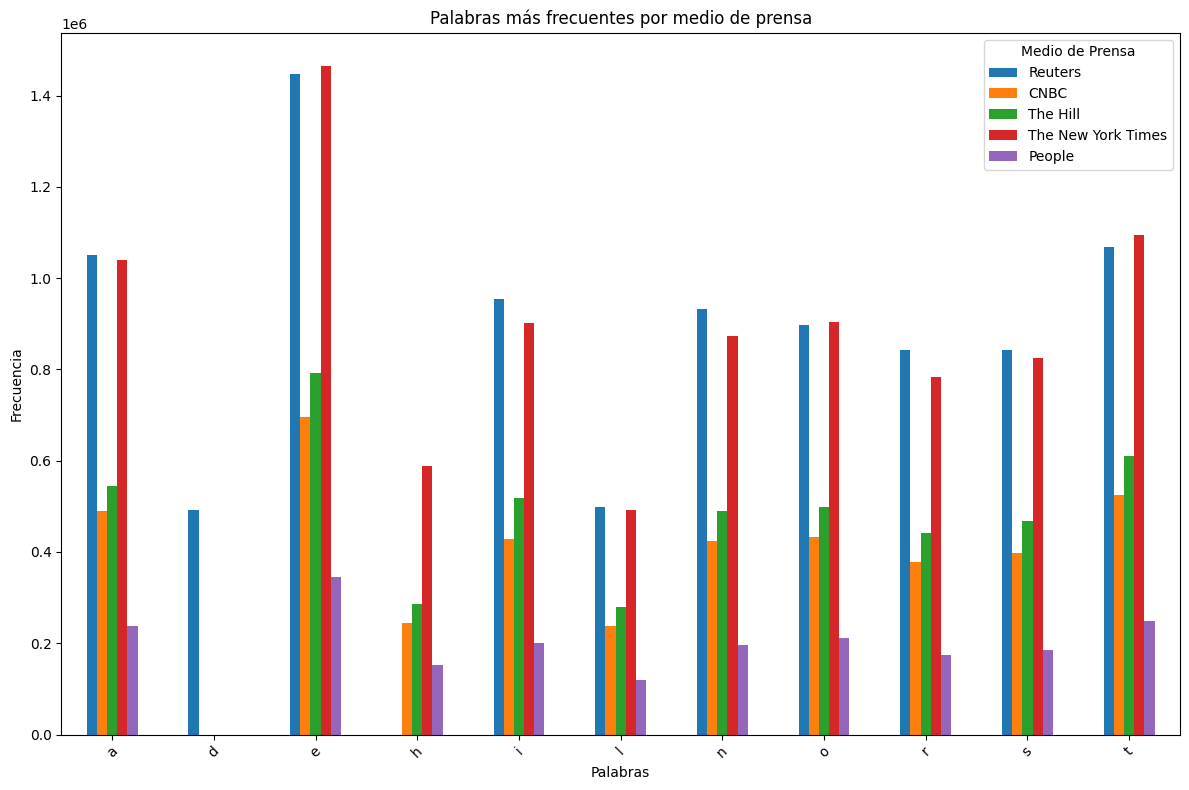

In [ ]:

# TODO: WordCloud para article
#WordCloud



stopwords = set(STOPWORDS)

# agregar palabras poco útiles en noticias
stopwords.update([
    # ruido general
    'show', 'work', 'might', 'though',

    # verbos genéricos
    'going', 'went', 'go',
    'say', 'saying',
    'make', 'made',
    'take', 'taken',
    'come', 'coming', 'came',
    'get', 'getting', 'got',

    # periodístico (pero no político fuerte)
    'reporting', 'statement', 'support', 'help','said','called'
    'deal', 'plan', 'issue', 'place', 'home', 'life', 'best',
    'says','including','used','called'

    # ruido residual
    'even', 'still', 'much', 'many', 'well','will','want','new','now',
    'one','two','three','four','five','year','us','time','monday','tuesday',
    'wednesday','thursday','friday','sathurday','sunday','day','see','week','us','they'
])

def clean_text_wordcloud(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
# Unir todo el texto limpio
text = " ".join(df['article'].dropna().astype(str).apply(clean_text_wordcloud))


wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    max_words=200,
    colormap='viridis'
).generate(text)

# Mostrar
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [ ]:
# TODO: Realice una visualización que permita comparar las palabras más frecuentes
# de cada uno de los cinco medios de prensa.
# - ¿Encuentra algún problema en los resultados?

word_freq = {}
for medio in df_top_5['publication'].unique():
    # Filtramos nulos, convertimos a string y unimos
    columna_limpia = df_top_5[df_top_5['publication'] == medio]['Cleantext'].dropna().astype(str)
    texto_completo = " ".join(columna_limpia)
    palabras = texto_completo.split()
    frecuencia = pd.Series(palabras).value_counts().head(10)
    word_freq[medio] = frecuencia

# Convertir el diccionario en un DataFrame para facilitar la visualización
df_word_freq = pd.DataFrame(word_freq).fillna(0)
df_word_freq.plot(kind='bar', figsize=(12, 8))
plt.title('Palabras más frecuentes por medio de prensa')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.legend(title='Medio de Prensa')
plt.tight_layout()
plt.show()

#se ve el problema de que las palabras más frecuentes son muy genéricas y no aportan información relevante sobre el medio de prensa. Esto puede deberse a que los artículos contienen muchas palabras comunes que no son distintivas de cada medio. Para mejorar esto, se podría considerar eliminar stop words o enfocarse en palabras clave específicas relacionadas con cada medio.


C:\Users\germa\AppData\Local\Temp\ipykernel_32744\3343879357.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5['Cleantext_Stopwords'] = clean_text_stopwords(df_top_5, 'Cleantext')


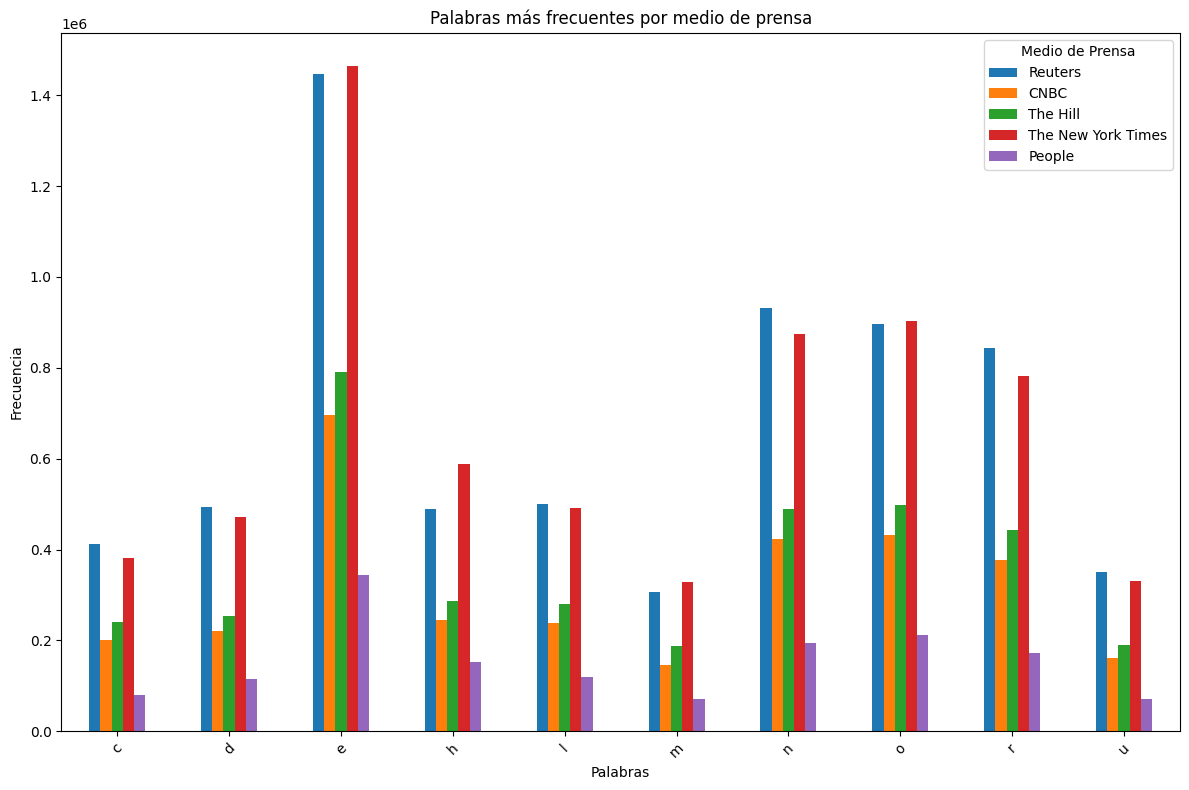

In [14]:

def clean_text_stopwords(df, column_name):
    
    result = df[column_name].astype(str).str.lower()
    result = result.str.replace(r'[^\w\s]', ' ', regex=True)
    stopwords = ["i","s", "t", "up", "down","in", "out", "the", "and", "is", "in", "to", "of", "a", "that", "it", "with", "as", "for", "was", "on", "are", "by", "this", "be", "from", "at", "or", "an", "which", "not", "all", "have", "has", "but", "they", "their", "its", "if", "we", "he", "she", "my", "me", "you", "his", "her", "them", "what", "who", "when", "where", "why", "how", "the", "and", "is", "in", "to", "of", "a", "that", "it", "with", "as", "for", "was", "on", "are", "by", "this", "be", "from", "at", "or", "an", "which", "not", "all", "have", "has", "but", "they", "their", "its", "if", "we", "he", "she", "my", "me", "you", "his", "her", "them"]
    
    for stopword in stopwords:     
        result = result.str.replace(rf"\b{stopword}\b", " ", regex=True)
    return result

df_top_5['Cleantext_Stopwords'] = clean_text_stopwords(df_top_5, 'Cleantext')

word_freq = {}
for medio in df_top_5['publication'].unique():
    # Filtramos nulos, convertimos a string y unimos
    columna_limpia = df_top_5[df_top_5['publication'] == medio]['Cleantext_Stopwords'].dropna().astype(str)
    texto_completo = " ".join(columna_limpia)
    palabras = texto_completo.split()
    frecuencia = pd.Series(palabras).value_counts().head(10)
    word_freq[medio] = frecuencia

# Convertir el diccionario en un DataFrame para facilitar la visualización
df_word_freq = pd.DataFrame(word_freq).fillna(0)
df_word_freq.plot(kind='bar', figsize=(12, 8))
plt.title('Palabras más frecuentes por medio de prensa')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.legend(title='Medio de Prensa')
plt.tight_layout()
plt.show()

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [ ]:
# TODO: Busque los medios con mayor cantidad de palabras

word_count = df_top_5.groupby('publication')['Cleantext_Stopwords'].apply(lambda x: x.str.split().str.len().sum())

print(f"\nCantidad total de palabras por medio:\n{word_count.sort_values(ascending=False)}")


Cantidad total de palabras por medio:
publication
Reuters               1780158.0
The New York Times    1661083.0
The Hill               934412.0
CNBC                   822477.0
People                 398161.0
Name: Cleantext_Stopwords, dtype: float64


## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [ ]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# 1. Aseguramos que los nombres de los medios estén limpios y en minúsculas para la búsqueda
medios = df_top_5['publication'].unique()
mentions_matrix = pd.DataFrame(0, index=medios, columns=medios)

# 2. Iteramos por cada medio de origen (filas)
for medio_origen in medios:
    # Obtenemos todos los textos de ese medio en una serie
    textos_del_medio = df_top_5[df_top_5['publication'] == medio_origen]['Cleantext'].astype(str).str.lower()
    
    # 3. Iteramos por cada medio objetivo (columnas)
    for medio_objetivo in medios:
        # Usamos una búsqueda simple de strings sobre toda la serie de textos
        # Esto cuenta cuántas veces aparece el nombre del 'medio_objetivo' 
        # en los artículos del 'medio_origen'
        nombre_buscar = medio_objetivo.lower()
        
        # Contamos cuántos artículos contienen el nombre del medio objetivo
        conteo = textos_del_medio.str.contains(rf'\b{nombre_buscar}\b', regex=True).sum()
        
        # 4. Asignamos el valor exacto a la celda
        mentions_matrix.loc[medio_origen, medio_objetivo] = conteo

print("\nMatriz de menciones:\n")
print(mentions_matrix)


Matriz de menciones:

                    Reuters  CNBC  The Hill  The New York Times  People
Reuters                8358    31         2                  29    1506
CNBC                    821   899         5                  46     811
The Hill                 71    13      2335                 127     959
The New York Times       45    13        15                 482    1590
People                    4     3         4                  38    1018


In [ ]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.



## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*